<a href="https://colab.research.google.com/github/nexageapps/AI/blob/main/Basic/B02%20-%20Linear%20Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lesson 2: Linear Regression

**Author:** Karthik Arjun  
**LinkedIn:** [karthik-arjun-a5b4a258](https://www.linkedin.com/in/karthik-arjun-a5b4a258/)  
**Created:** 2026  
**Updated:** 2026

## Learning Objectives
- Understand what linear regression is and when to use it
- Learn about the relationship between input features and output predictions
- Implement a simple linear regression model using TensorFlow/Keras
- Visualize predictions and understand model parameters (weights and bias)

## Prerequisites
- Completed L1 (Arithmetic Operations)
- Basic understanding of Python
- Familiarity with mathematical operations

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers

print(f"TensorFlow version: {tf.__version__}")

2026-03-06 20:22:08.764084: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version: 2.16.2


## 1. What is Linear Regression?

Linear regression is a method to predict a continuous output value based on input features.

**Real-world examples:**
- Predicting house prices based on size
- Estimating salary based on years of experience
- Forecasting sales based on advertising spend

**Mathematical Formula:**
```
y = mx + b
```
Where:
- `y` = predicted output
- `m` = weight (slope)
- `x` = input feature
- `b` = bias (intercept)

## 2. Create Training Data

Let's create a simple dataset: predicting exam scores based on study hours.

**Scenario:** Students who study more hours tend to score higher on exams.

Training Data:
Study Hours: [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]
Exam Scores: [27. 30. 35. 40. 54. 65. 76. 81. 86. 91.]


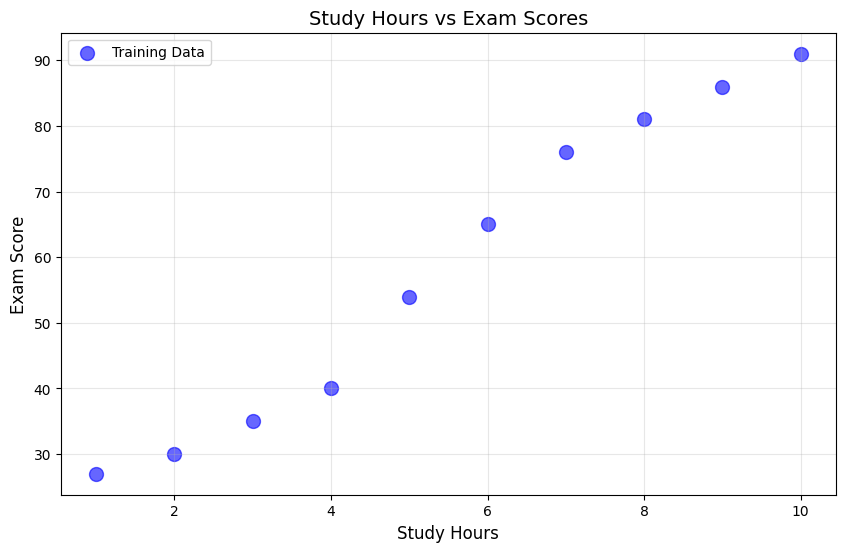

In [4]:
# Training data: [study hours]
X_train = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10], dtype=float)

# Training labels: [exam scores]
# Roughly: score = 20 * hours + 7 (with some noise)
y_train = np.array([27, 30, 35, 40, 54, 65, 76, 81, 86, 91], dtype=float)

print("Training Data:")
print(f"Study Hours: {X_train}")
print(f"Exam Scores: {y_train}")

# Visualize the data
plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, color='blue', s=100, alpha=0.6, label='Training Data')
plt.xlabel('Study Hours', fontsize=12)
plt.ylabel('Exam Score', fontsize=12)
plt.title('Study Hours vs Exam Scores', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 3. Build the Model

We'll create a simple neural network with:
- **Input:** 1 feature (study hours)
- **Output:** 1 value (exam score)
- **Architecture:** Single Dense layer with 1 neuron

In [5]:
# Create the model
model = keras.Sequential([
    layers.Dense(units=1, input_shape=[1])
])

# Compile the model
model.compile(
    optimizer='sgd',  # Stochastic Gradient Descent
    loss='mean_squared_error'  # MSE for regression
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

## 4. Train the Model

Training means finding the best values for weight (m) and bias (b) that minimize the error.

Training the model...
Training complete!


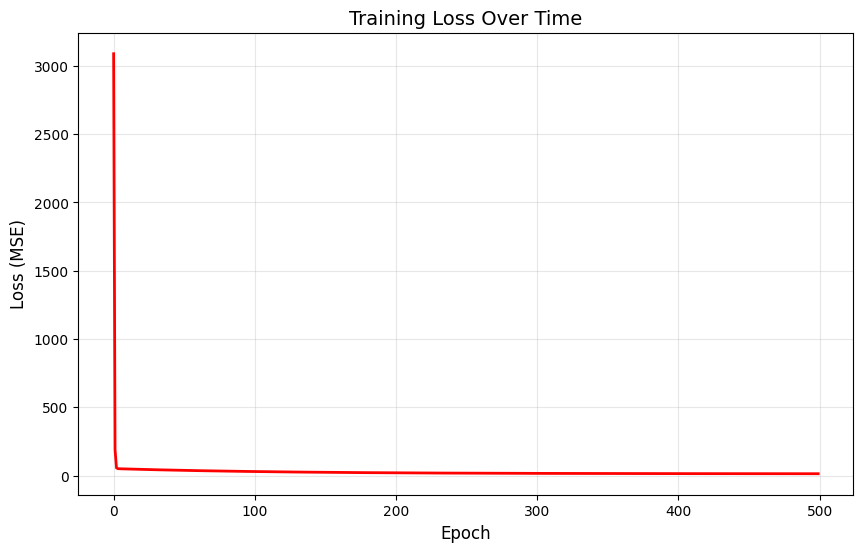

In [6]:
# Train the model
print("Training the model...")
history = model.fit(
    X_train, 
    y_train, 
    epochs=500,
    verbose=0  # Silent training
)

print("Training complete!")

# Plot training loss
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], color='red', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.title('Training Loss Over Time', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

## 5. Examine Model Parameters

Let's look at the learned weight and bias.

In [7]:
# Get model parameters
weights, bias = model.layers[0].get_weights()

print("\nLearned Parameters:")
print(f"Weight (m): {weights[0][0]:.4f}")
print(f"Bias (b): {bias[0]:.4f}")
print(f"\nEquation: y = {weights[0][0]:.4f}x + {bias[0]:.4f}")
print("\nExpected: y ≈ 20x + 7")


Learned Parameters:
Weight (m): 8.2157
Bias (b): 12.9721

Equation: y = 8.2157x + 12.9721

Expected: y ≈ 20x + 7


## 6. Make Predictions

Now let's use our trained model to predict exam scores for new study hours.

In [8]:
# Test data
X_test = np.array([2.5, 5.5, 8.5], dtype=float)

# Make predictions
predictions = model.predict(X_test)

print("\nPredictions:")
for hours, score in zip(X_test, predictions):
    print(f"Study Hours: {hours:.1f} → Predicted Score: {score[0]:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step

Predictions:
Study Hours: 2.5 → Predicted Score: 33.51
Study Hours: 5.5 → Predicted Score: 58.16
Study Hours: 8.5 → Predicted Score: 82.81


## 7. Visualize Results

Let's plot the training data and the model's predictions.

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


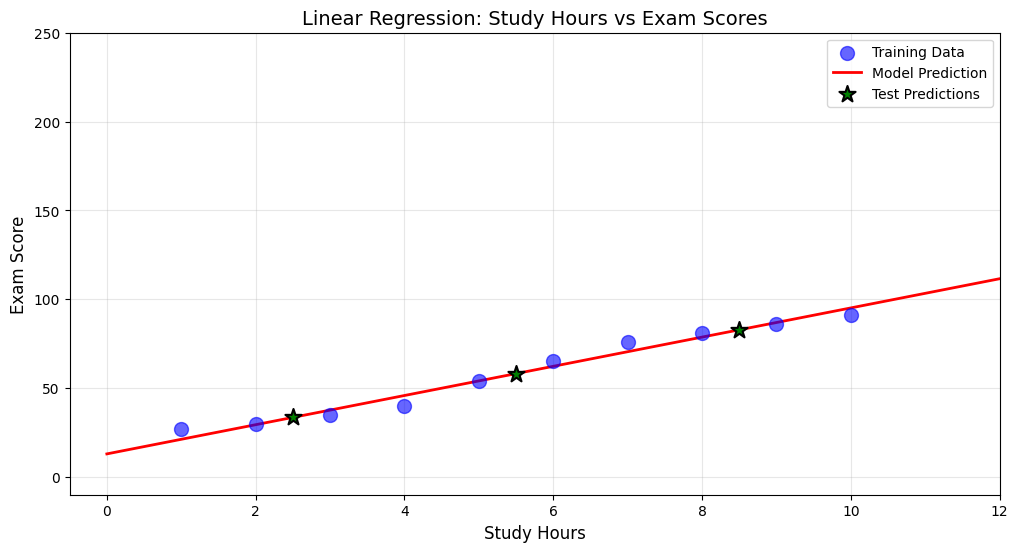

In [9]:
# Generate predictions for a range of values
X_range = np.linspace(0, 12, 100)
y_pred = model.predict(X_range)

# Plot
plt.figure(figsize=(12, 6))

# Training data
plt.scatter(X_train, y_train, color='blue', s=100, alpha=0.6, label='Training Data', zorder=3)

# Model predictions
plt.plot(X_range, y_pred, color='red', linewidth=2, label='Model Prediction', zorder=2)

# Test predictions
plt.scatter(X_test, predictions, color='green', s=150, marker='*', 
            label='Test Predictions', zorder=4, edgecolors='black', linewidth=1.5)

plt.xlabel('Study Hours', fontsize=12)
plt.ylabel('Exam Score', fontsize=12)
plt.title('Linear Regression: Study Hours vs Exam Scores', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.xlim(-0.5, 12)
plt.ylim(-10, 250)
plt.show()

## 8. Understanding the Results

### What did we learn?

1. **The model found a linear relationship** between study hours and exam scores
2. **Weight (m)** tells us how much the score increases per study hour (~20 points)
3. **Bias (b)** is the baseline score with 0 study hours (~7 points)
4. **Loss decreased** during training, meaning the model improved

### Key Concepts:
- **Training:** Finding the best parameters (weight and bias)
- **Loss Function:** Measures how wrong our predictions are
- **Optimizer:** Algorithm that adjusts parameters to minimize loss
- **Epochs:** Number of times the model sees the entire dataset

## 9. Experiment: Try Different Data

Let's see how the model performs with different relationships.

New Model Parameters:
Weight: 15.6319
Bias: 26.4475

Expected: Weight = 15, Bias = 30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


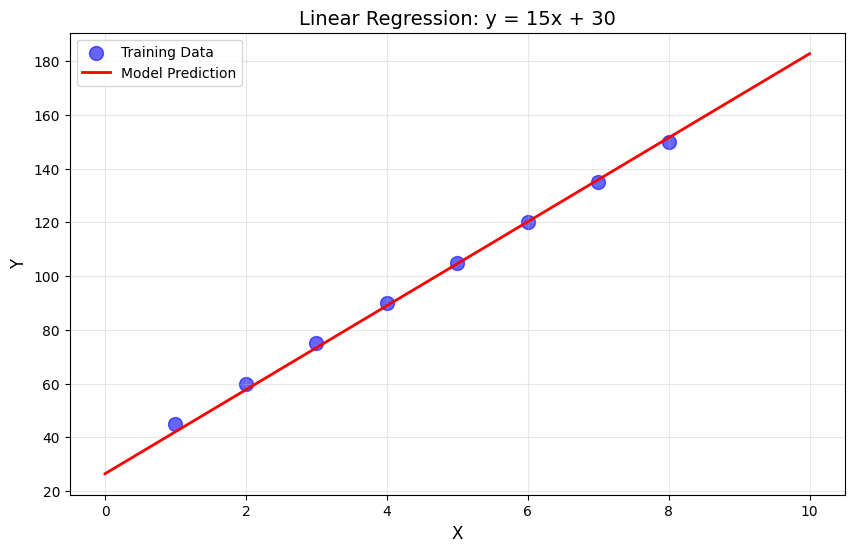

In [10]:
# Create new data with different relationship
# Relationship: y = 15x + 30
X_new = np.array([1, 2, 3, 4, 5, 6, 7, 8], dtype=float)
y_new = 15 * X_new + 30

# Create and train new model
model_new = keras.Sequential([layers.Dense(units=1, input_shape=[1])])
model_new.compile(optimizer='sgd', loss='mean_squared_error')
model_new.fit(X_new, y_new, epochs=500, verbose=0)

# Get parameters
weights_new, bias_new = model_new.layers[0].get_weights()

print("New Model Parameters:")
print(f"Weight: {weights_new[0][0]:.4f}")
print(f"Bias: {bias_new[0]:.4f}")
print(f"\nExpected: Weight = 15, Bias = 30")

# Visualize
X_range_new = np.linspace(0, 10, 100)
y_pred_new = model_new.predict(X_range_new)

plt.figure(figsize=(10, 6))
plt.scatter(X_new, y_new, color='blue', s=100, alpha=0.6, label='Training Data')
plt.plot(X_range_new, y_pred_new, color='red', linewidth=2, label='Model Prediction')
plt.xlabel('X', fontsize=12)
plt.ylabel('Y', fontsize=12)
plt.title('Linear Regression: y = 15x + 30', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 10. Key Takeaways

1. **Linear regression** finds a straight line that best fits the data
2. **Weight** determines the slope of the line
3. **Bias** determines where the line crosses the y-axis
4. **Training** is the process of finding optimal weight and bias
5. **Loss function** (MSE) measures prediction error
6. The model can **generalize** to predict values it hasn't seen

## Next Steps (L3)
- Learn about classification problems
- Understand sigmoid activation function
- Build a binary classifier

## References
- TensorFlow Documentation: https://www.tensorflow.org/
- Linear Regression: https://en.wikipedia.org/wiki/Linear_regression

---

## Key Takeaways

**Relevant UoA Courses:** COMPSCI 762, COMPSCI 713

1. Linear regression finds the best-fit line: y = wx + b
2. Loss function (MSE) measures prediction error: L = (y_pred - y_true)²
3. Gradient descent iteratively updates weights: w = w - α∇L
4. Learning rate (α) controls step size - too large diverges, too small is slow
5. Convergence occurs when loss stops decreasing significantly

---

## Exam Preparation Guide

### Essential Concepts for Exams

- Be able to derive gradients: ∂L/∂w and ∂L/∂b for MSE loss
- Understand gradient descent update rule and how learning rate affects it
- Know when to use batch vs stochastic vs mini-batch gradient descent
- Calculate loss given predictions and true values
- Explain overfitting vs underfitting in context of linear models

### Common Mistakes to Avoid

- ❌ Forgetting to update both weights and bias
- ❌ Using wrong sign in gradient descent (should subtract gradient)
- ❌ Not normalizing features leading to slow convergence

### Practice Problems

1. Given loss L = (wx + b - y)², derive ∂L/∂w and ∂L/∂b
2. If loss increases after update, what's likely wrong?
3. Compare convergence speed: α=0.001 vs α=0.1 vs α=1.0

### How This Helps Your UoA Courses

**COMPSCI 762, COMPSCI 713:**
- Provides hands-on implementation of theoretical concepts
- Practice problems similar to exam questions
- Reinforces lecture material with code examples
- Helps build intuition for complex topics

### Study Tips

1. **Understand, Don't Memorize**: Focus on why, not just what
2. **Practice Calculations**: Work through problems by hand
3. **Connect to Theory**: Link code to mathematical formulations
4. **Teach Others**: Explaining concepts solidifies understanding
5. **Review Regularly**: Spaced repetition improves retention

### Exam Question Types

- **Conceptual**: Explain why/how something works
- **Calculation**: Compute outputs, gradients, shapes
- **Comparison**: Compare approaches, trade-offs
- **Application**: Design solution for given problem
- **Debugging**: Identify and fix issues

---


---

## Learning Progress Tracker

Use this section to track your learning progress for this lesson.

### Completion Status
- [ ] Lesson completed
- [ ] All code cells executed successfully
- [ ] Understood all key concepts
- [ ] Completed practice exercises (if any)

### Dates
- **First Completed:** ____/____/____
- **Last Reviewed:** ____/____/____
- **Next Review:** ____/____/____ (Recommended: 1 week, 1 month, 3 months)

### Understanding Level
Rate your understanding (1-5): _____ / 5

- 1 = Need to review completely
- 2 = Understood basics, need more practice
- 3 = Good understanding, minor gaps
- 4 = Strong understanding, can explain to others
- 5 = Mastered, can apply in projects

### Notes & Reflections
```
Write your notes here:
- What concepts were challenging?
- What was interesting or surprising?
- How can you apply this in projects?
- Questions to explore further?




```

### Key Concepts to Remember (B02)
- [ ] Linear regression fundamentals
- [ ] Gradient descent optimization
- [ ] Loss functions (MSE)
- [ ] Model training and evaluation

---